In [107]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [108]:
# ========= 1. 設定 (Configuration) =========

base_dir = r"C:\experiment\1D"

experiments = [
    {"file": os.path.join(base_dir, "t0103", "t0103.csv"), "group_val":  5, "group": "5cm"},
    {"file": os.path.join(base_dir, "t0104", "t0104.csv"), "group_val":  7, "group": "7cm"},
    {"file": os.path.join(base_dir, "t0105", "t0105.csv"), "group_val": 10, "group": "10cm"},
    {"file": os.path.join(base_dir, "t0106", "t0106.csv"), "group_val": 12, "group": "12cm"},
    {"file": os.path.join(base_dir, "t0100", "t0100.csv"), "group_val": 15, "group": "15cm"},
    # {"file": os.path.join(base_dir, "t0107", "t0107.csv"), "group_val": 15, "group": "150P"},
]

# 繪圖 X 軸 (Normal Stress) 範圍
xlim_min = 6
xlim_max = 34


In [109]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan


def process_data(target_metric):
    """ 讀取 CSV 並計算在每個 sigma 下的 median 與 IQR """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue

        df = pd.read_csv(exp['file'])

        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()

        if target_metric == 'k' and 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]

        if target_metric not in df.columns:
            continue

        # 萃取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])

        # 計算每個 sigma 的統計量
        stats = df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data


def process_delta_data():
    """
    讀取 CSV，計算 delta：
    1. 每筆資料計算 delta_E2、delta_E3、delta_E4 的平均
    2. 按 sigma 分組，計算中位數與 IQR
    """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue

        df = pd.read_csv(exp['file'])

        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()

        # 檢查必要欄
        required_cols = ['delta_E2', 'delta_E3', 'delta_E4']
        if not all(c in df.columns for c in required_cols):
            continue

        # 數值化
        for c in required_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        # 去除任一欄為 NaN 的列
        df = df.dropna(subset=required_cols)

        # 計算每筆資料的 delta 均值 (E2+E3+E4)/3
        df['delta_avg'] = df[required_cols].mean(axis=1)

        # 萃取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', 'delta_avg'])

        # 計算每個 sigma 的統計量
        stats = df.groupby('sigma')['delta_avg'].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data


In [110]:
custom_colors = ['#F4A63A', '#A2C4F1', '#A5D1B0', '#DF562C', '#CEBAF0', '#293890', '#E8D2B3']


In [111]:
# ========= 3. 繪圖函式 (Plotting Function) =========

def plot_metric(target_metric, title, ylabel, use_delta=False):
    """以 sigma 為 X 軸繪圖，不同 group 各一條序列。"""
    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)

    if not data_to_plot:
        print(f"找不到 {target_metric} 欄")
        return

    # colormap：以 group_val 排序對應 custom_colors
    group_vals = [item['group_val'] for item in data_to_plot]
    n = len(group_vals)
    colors = custom_colors[:n]
    val_to_idx = {v: i for i, v in enumerate(group_vals)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))

    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        color = colors[val_to_idx[item['group_val']]]

        all_sigmas.extend(sigmas)

        ax.errorbar(
            sigmas, medians,
            yerr=[yerr_lower, yerr_upper],
            fmt='s', color=color,
            markersize=8, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=0.8, zorder=3
        )

        # 趨勢線
        if len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    # 繪製趨勢線標籤（防重疊）
    if texts_to_draw:
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min if y_max != y_min else 1
        min_dist = y_range * 0.05
        texts_to_draw.sort(key=lambda t: t['y'])
        for j in range(1, len(texts_to_draw)):
            if texts_to_draw[j]['y'] - texts_to_draw[j-1]['y'] < min_dist:
                texts_to_draw[j]['y'] = texts_to_draw[j-1]['y'] + min_dist
        for t in texts_to_draw:
            ax.text(t['x'], t['y'], t['text'], color=t['color'],
                    fontsize=11, fontweight='bold', va='center')

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)

    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label('VW Patch Length', fontsize=12)
    cbar.ax.set_yticklabels([item['group'] for item in data_to_plot])
    plt.tight_layout()
    plt.show()


In [112]:
# ========= 4. 以群組為 X 軸繪圖函式 (Group X-Axis Plotting Function) =========

def plot_metric_by_group(target_metric, title, ylabel, use_delta=False):
    """以群組為 X 軸（數值型），不同 sigma 各一條序列。"""
    group_order = [exp['group'] for exp in experiments]
    group_xval  = {exp['group']: exp['group_val'] for exp in experiments}

    if use_delta:
        data_to_plot = process_delta_data()
    else:
        data_to_plot = process_data(target_metric)

    if not data_to_plot:
        print(f"找不到 {target_metric} 欄")
        return

    # 收集所有出現的 sigma
    all_sigmas_set = set()
    for item in data_to_plot:
        all_sigmas_set.update(item['stats']['sigma'].values)
    unique_sigmas = sorted(all_sigmas_set)

    # colormap：以 sigma 排序對應 custom_colors
    n = len(unique_sigmas)
    colors = custom_colors[:n]
    sigma_to_idx = {s: i for i, s in enumerate(unique_sigmas)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item['group']
            if group not in group_xval:
                continue
            stats = item['stats']
            row = stats[stats['sigma'] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row['median'].values[0]
            q1  = row['q1'].values[0]
            q3  = row['q3'].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color = colors[sigma_to_idx[sigma]]

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt='s', color=color,
            markersize=10, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=1, zorder=3
        )

        # 趨勢線
        if len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.1,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    # 繪製趨勢線標籤（防重疊）
    if texts_to_draw:
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min if y_max != y_min else 1
        min_dist = y_range * 0.05
        texts_to_draw.sort(key=lambda t: t['y'])
        for j in range(1, len(texts_to_draw)):
            if texts_to_draw[j]['y'] - texts_to_draw[j-1]['y'] < min_dist:
                texts_to_draw[j]['y'] = texts_to_draw[j-1]['y'] + min_dist
        for t in texts_to_draw:
            ax.text(t['x'], t['y'], t['text'], color=t['color'],
                    fontsize=11, fontweight='bold', va='center')

    ax.set_xlabel('VW Patch Length', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    x_vals_all = list(group_xval.values())
    ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    ax.set_xticks(x_vals_all)
    ax.set_xticklabels(group_order)
    ax.grid(axis='y', alpha=0.6)

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    cbar.ax.set_yticklabels([f'{s:.0f} MPa' for s in unique_sigmas])
    plt.tight_layout()
    plt.show()


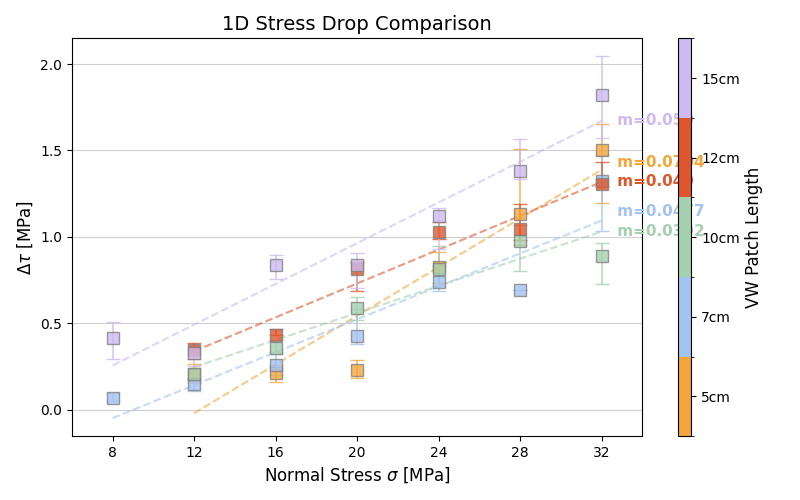

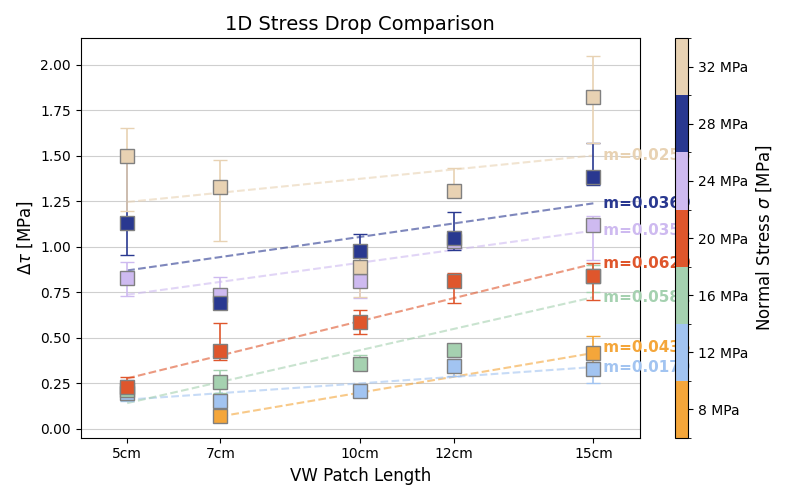

In [113]:
# ========= 5. 繪製 Tau Drop =========
plot_metric('delta_tau', r'1D Stress Drop Comparison', r'$\Delta\tau$ [MPa]')
# ========= 8. 以群組為 X 軸：Tau Drop =========
plot_metric_by_group('delta_tau', r'1D Stress Drop Comparison', r'$\Delta\tau$ [MPa]')

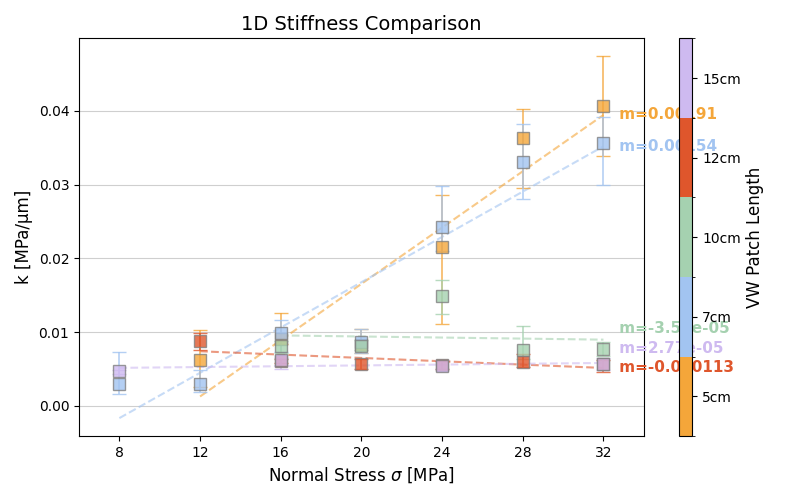

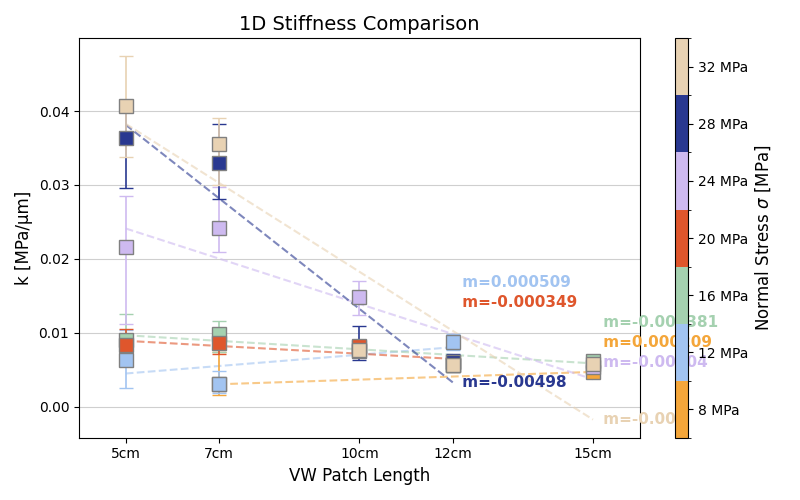

In [114]:
# ========= 6. 繪製 K Stiffness =========
plot_metric('k', '1D Stiffness Comparison', 'k [MPa/\u03bcm]')
# ========= 9. 以群組為 X 軸：K Stiffness =========
plot_metric_by_group('k', '1D Stiffness Comparison', 'k [MPa/\u03bcm]')



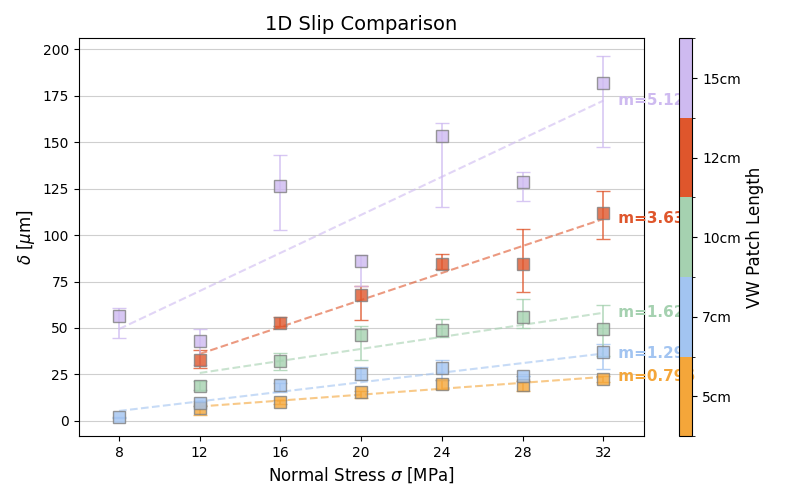

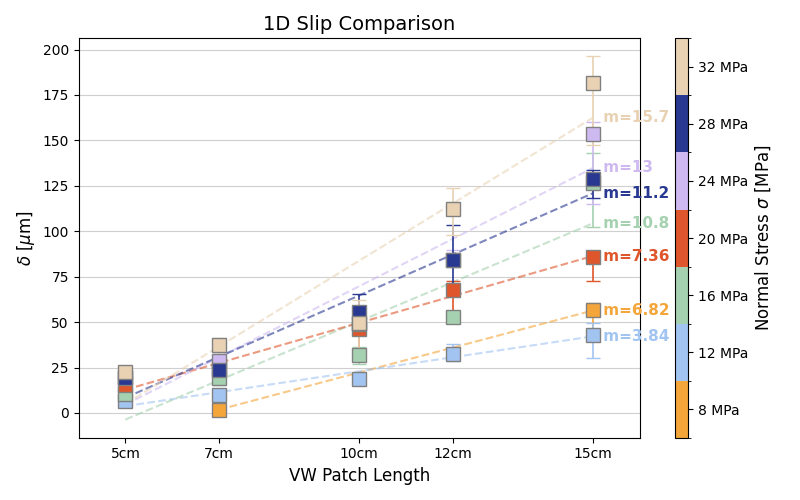

In [115]:
# ========= 7. 繪製 Delta (E2+E3+E4 平均) =========
plot_metric('delta_avg', r'1D Slip Comparison', r'$\delta$ [$\mu$m]', use_delta=True)
# ========= 10. 以群組為 X 軸：Delta =========
plot_metric_by_group('delta_avg', r'1D Slip Comparison', r'$\delta$ [$\mu$m]', use_delta=True)